In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load the shard of daily data (Contains all stocks OHCLV from 2000-2026)
df = pd.read_parquet("hf://datasets/xxparthparekhxx/indian-stock-market-minute-data/day/train-00000.parquet")
df.tail()

,symbol,timestamp,open,high,low,close,volume,oi
6968611,ZYDUSWELL,2026-01-15 18:30:00+00:00,446.000000,448.700012,433.299988,439.700012,127170,0
6968612,ZYDUSWELL,2026-01-18 18:30:00+00:00,439.700012,440.000000,420.000000,425.250000,216032,0
6968613,ZYDUSWELL,2026-01-19 18:30:00+00:00,425.200012,426.850006,413.549988,416.700012,194843,0
6968614,ZYDUSWELL,2026-01-20 18:30:00+00:00,418.799988,429.700012,410.149994,425.399994,157978,0
6968615,ZYDUSWELL,2026-01-21 18:30:00+00:00,425.700012,435.000000,425.399994,431.700012,103170,0


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6968616 entries, 0 to 6968615
Data columns (total 8 columns):
 #   Column     Dtype              
---  ------     -----              
 0   symbol     str                
 1   timestamp  datetime64[us, UTC]
 2   open       float32            
 3   high       float32            
 4   low        float32            
 5   close      float32            
 6   volume     int64              
 7   oi         int64              
dtypes: datetime64[us, UTC](1), float32(4), int64(2), str(1)
memory usage: 370.9 MB


In [ ]:
unique_symbol_df = pd.DataFrame(df["symbol"].unique(), columns=["unique_symbols"])
unique_symbol_df.head()

,unique_symbols
0,20MICRONS
1,21STCENMGM
2,360ONE
3,3IINFOLTD
4,3MINDIA


In [ ]:
df.sort_values(by=["volume"], ascending=False)

,symbol,timestamp,open,high,low,close,volume,oi
2554354,IDEA,2024-04-24 18:30:00+00:00,11.800000,14.400000,11.800000,13.900000,8453266674,0
2208405,GTLINFRA,2020-07-12 18:30:00+00:00,0.900000,0.900000,0.900000,0.900000,6161122183,0
5010035,PRIVISCL,2020-02-25 18:30:00+00:00,0.100000,0.150000,0.100000,0.150000,4146070000,0
2554355,IDEA,2024-04-25 18:30:00+00:00,13.650000,14.200000,12.700000,14.000000,3867133280,0
5010029,PRIVISCL,2020-02-16 18:30:00+00:00,0.100000,0.150000,0.100000,0.150000,3510465000,0
...,...,...,...,...,...,...,...,...
4398309,NIFTY MIDCAP 50,2024-01-03 18:30:00+00:00,13272.599609,13474.000000,13258.700195,13455.200195,0,0
4398308,NIFTY MIDCAP 50,2024-01-02 18:30:00+00:00,13207.950195,13274.400391,13108.549805,13226.099609,0,0
4398307,NIFTY MIDCAP 50,2024-01-01 18:30:00+00:00,13261.450195,13271.400391,13046.349609,13198.349609,0,0
4398299,NIFTY MIDCAP 50,2023-12-19 18:30:00+00:00,13044.150391,13117.000000,12504.099609,12560.000000,0,0


In [ ]:
# no missing values in the dataset
df.isna().sum()

symbol       0
timestamp    0
open         0
high         0
low          0
close        0
volume       0
oi           0
dtype: int64

In [ ]:
# locating any outliers where high < open and high < close
df.loc[(df['high'] < df['open']) | (df['high'] < df['close'])]

,symbol,timestamp,open,high,low,close,volume,oi
179811,AHLEAST,2013-04-09 18:30:00+00:00,102.150002,102.150002,102.150002,119.449997,75,0
179812,AHLEAST,2013-04-10 18:30:00+00:00,102.150002,102.150002,102.150002,119.449997,0,0
252003,ALKYLAMINE,2011-01-04 18:30:00+00:00,17.600000,18.299999,17.600000,18.400000,90,0
262524,ALLDIGI,2013-04-09 18:30:00+00:00,52.900002,52.900002,52.349998,55.099998,850,0
262525,ALLDIGI,2013-04-10 18:30:00+00:00,52.900002,52.900002,52.349998,55.099998,0,0
...,...,...,...,...,...,...,...,...
6871307,WSI,2013-04-10 18:30:00+00:00,12.050000,12.050000,12.050000,13.000000,0,0
6871308,WSI,2013-04-11 18:30:00+00:00,12.050000,12.050000,12.050000,13.000000,0,0
6871309,WSI,2013-04-14 18:30:00+00:00,12.050000,12.050000,12.050000,13.000000,0,0
6871310,WSI,2013-04-15 18:30:00+00:00,12.050000,12.050000,12.050000,13.000000,0,0


In [ ]:
# converting the given UTC timestamp into IST timestamp
df['timestamp_local'] = df['timestamp'].dt.tz_convert("Asia/Kolkata")
df.drop(columns="timestamp", inplace=True)
df

,symbol,open,high,low,close,volume,oi,timestamp_local
0,20MICRONS,40.000000,40.000000,15.800000,16.820000,23501730,0,2008-10-06 00:00:00+05:30
1,20MICRONS,16.000000,19.000000,13.930000,15.050000,9113422,0,2008-10-07 00:00:00+05:30
2,20MICRONS,14.000000,14.600000,12.550000,13.250000,2464384,0,2008-10-08 00:00:00+05:30
3,20MICRONS,12.450000,12.450000,10.820000,11.600000,1207928,0,2008-10-10 00:00:00+05:30
4,20MICRONS,12.150000,13.300000,11.650000,12.320000,898692,0,2008-10-13 00:00:00+05:30
...,...,...,...,...,...,...,...,...
6968611,ZYDUSWELL,446.000000,448.700012,433.299988,439.700012,127170,0,2026-01-16 00:00:00+05:30
6968612,ZYDUSWELL,439.700012,440.000000,420.000000,425.250000,216032,0,2026-01-19 00:00:00+05:30
6968613,ZYDUSWELL,425.200012,426.850006,413.549988,416.700012,194843,0,2026-01-20 00:00:00+05:30
6968614,ZYDUSWELL,418.799988,429.700012,410.149994,425.399994,157978,0,2026-01-21 00:00:00+05:30


In [ ]:
df["daily_returns_percent"] = (df["close"] - df["open"]) * 100 / df["open"]
df['avg_daily'] = df['low'] + (df['high'] - df['low']) / 2
df

,symbol,open,high,low,close,volume,oi,timestamp_local,daily_returns_percent,avg_daily
0,20MICRONS,40.000000,40.000000,15.800000,16.820000,23501730,0,2008-10-06 00:00:00+05:30,-57.950001,27.900002
1,20MICRONS,16.000000,19.000000,13.930000,15.050000,9113422,0,2008-10-07 00:00:00+05:30,-5.937499,16.465000
2,20MICRONS,14.000000,14.600000,12.550000,13.250000,2464384,0,2008-10-08 00:00:00+05:30,-5.357143,13.575001
3,20MICRONS,12.450000,12.450000,10.820000,11.600000,1207928,0,2008-10-10 00:00:00+05:30,-6.827304,11.635000
4,20MICRONS,12.150000,13.300000,11.650000,12.320000,898692,0,2008-10-13 00:00:00+05:30,1.399178,12.475000
...,...,...,...,...,...,...,...,...,...,...
6968611,ZYDUSWELL,446.000000,448.700012,433.299988,439.700012,127170,0,2026-01-16 00:00:00+05:30,-1.412553,441.000000
6968612,ZYDUSWELL,439.700012,440.000000,420.000000,425.250000,216032,0,2026-01-19 00:00:00+05:30,-3.286334,430.000000
6968613,ZYDUSWELL,425.200012,426.850006,413.549988,416.700012,194843,0,2026-01-20 00:00:00+05:30,-1.999059,420.200012
6968614,ZYDUSWELL,418.799988,429.700012,410.149994,425.399994,157978,0,2026-01-21 00:00:00+05:30,1.575933,419.924988


In [ ]:
# Total daily_returns_percent which are inf in the whole df
# (df['daily_returns_percent'] == np.inf).value_counts()
(df['open'] == 0).value_counts()

open
False    6967724
True         892
Name: count, dtype: int64

In [ ]:
df[df['open']==0]['symbol'].value_counts().head()

symbol
VEDL                 470
NIFTY50 DIV POINT    336
GNFC                  47
ASHOKLEY              31
MAZDOCK                8
Name: count, dtype: int64

In [ ]:
# Dropping rows with opening price 0 since it isn't practically possible and these consists of either newly-listed stocks with no data or illiquid stocks
new_df = df.drop(df[df['open'] == 0].index)
new_df.shape

(6967724, 10)

#### **Merging the modified dataframe (new_df) with NIFTY50**

In [ ]:
# 48/50 Nifty constituents matched successfully.
# TATAMOTORS and HDFC were not present in the historical price dataset,
# likely due to dataset coverage or ticker-composition differences between sources.

nifty_df = pd.read_csv('/content/nifty-50-stock-list.csv')
common = set(df['symbol']) & set(nifty_df['symbol'])
print(len(common))
print(set(nifty_df['symbol']) - set(df['symbol']))

48
{'HDFC', 'TATAMOTORS'}


In [ ]:
# Adding avg_daily and daily_return_percent column and filtering on symbols containing NIFTY50 only

print(df[df["symbol"].str.contains("TATA")].nunique()['symbol'])
print(df[df["symbol"].str.contains("HDFC")].nunique()['symbol'])

11
22


In [ ]:
# Percentage of portfolio coverage of NIFTY50
coverage = len(common) / len(set(nifty_df['symbol'])) * 100
coverage

96.0

In [ ]:
# merging the two dataframes
final_df = pd.merge(left = new_df, right = nifty_df, on = 'symbol', how = 'left')
final_df.shape

(6967724, 12)

In [ ]:
niftyfull_df = final_df[final_df['Sector'].notna()].copy()
niftyfull_df = niftyfull_df.sort_values(by=['symbol', 'timestamp_local'])
niftyfull_df['daily_returns_percent'] = niftyfull_df.groupby('symbol')['close'].pct_change() * 100
niftyfull_df = niftyfull_df.dropna(subset=['daily_returns_percent'])

Text(0.5, 1.0, 'NIFTY50 average daily returns (2000-2026)')

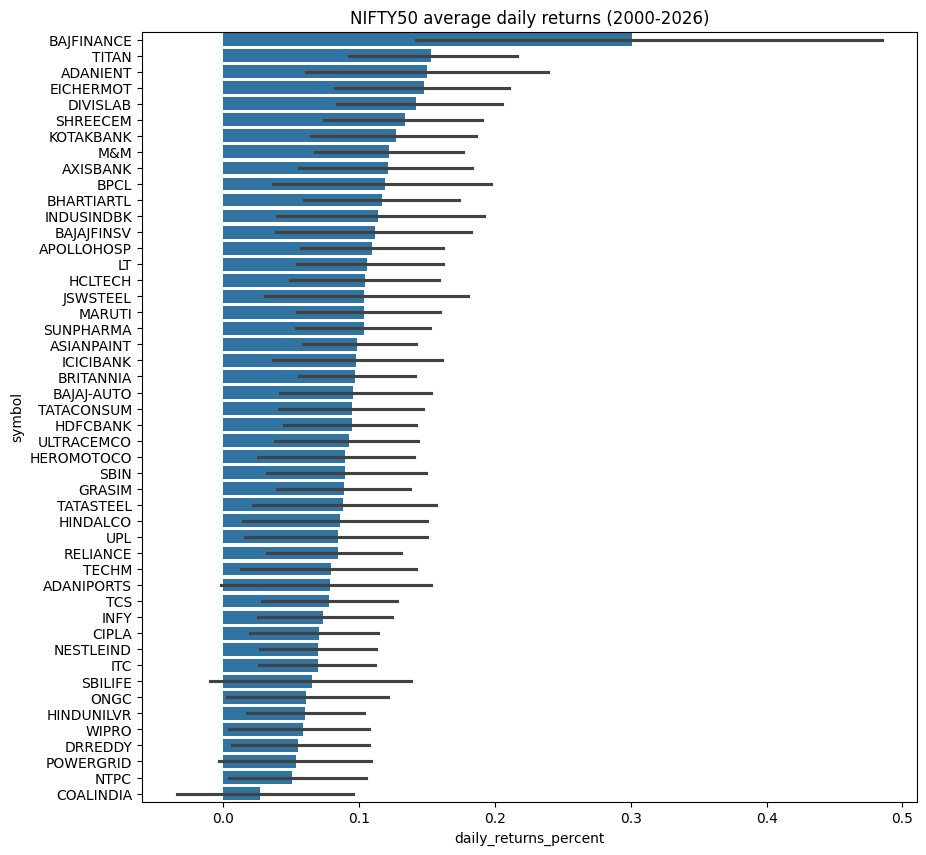

In [ ]:
plt.figure(figsize=[10, 10])
sorted_order = niftyfull_df.groupby('symbol')['daily_returns_percent'].mean().sort_values(ascending = False).index
sns.barplot(data = niftyfull_df, y = 'symbol', x = 'daily_returns_percent', order = sorted_order)
plt.title('NIFTY50 average daily returns (2000-2026)')

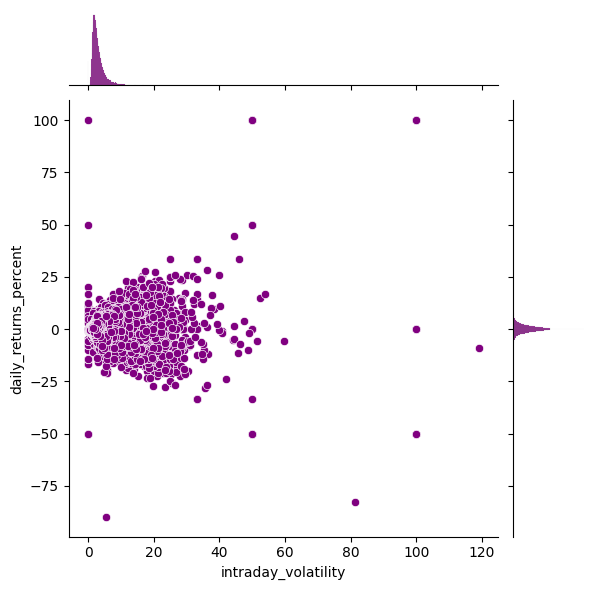

In [ ]:
# Intraday volatility to daily_returns_percent jointplot
niftyfull_df['intraday_volatility'] = (niftyfull_df['high'] - niftyfull_df['low']) / niftyfull_df['open'] * 100
sns.jointplot(data = niftyfull_df, x = 'intraday_volatility', y = 'daily_returns_percent', kind = 'scatter', color = 'purple')

In [ ]:
sector_avg = niftyfull_df.groupby('Sector')['avg_daily'].mean()
sector_avg

Sector
Automobile                2370.129395
Cement                    5267.148438
Chemicals                  326.194000
Construction              1140.129761
Consumer Durables          980.968933
FMCG                       786.418274
Financial Services         415.046295
Healthcare                1030.829468
Information Technology     667.054749
Metals & Mining            315.747101
Oil & Gas                  243.743973
Power                      132.966171
Services                   446.560822
Telecommunication          484.288910
Name: avg_daily, dtype: float32

In [ ]:
sector_volume = niftyfull_df.groupby('Sector')['volume'].mean()
sector_volume

Sector
Automobile                1.272686e+06
Cement                    4.135562e+05
Chemicals                 2.011671e+06
Construction              3.725705e+06
Consumer Durables         2.514415e+06
FMCG                      4.369481e+06
Financial Services        1.138581e+07
Healthcare                1.824335e+06
Information Technology    6.456243e+06
Metals & Mining           2.051504e+07
Oil & Gas                 1.744046e+07
Power                     1.016731e+07
Services                  4.122071e+06
Telecommunication         6.756107e+06
Name: volume, dtype: float64

In [ ]:
# plt.figure(figsize=(14, 8))
# showfliers=False outliers ko hata dega visually
# sns.boxplot(data=niftyfull_df, x='Sector', y='daily_returns_percent', showfliers=False)
# plt.xticks(rotation=45) # Sector names overlap na hon
# plt.title("Distribution of Daily Returns by Sector (Without Outliers)")
niftyfull_df.shape

(256444, 13)

### **Phase 2: Feature Engineering**

In [ ]:
!pip install pandas-ta

In [ ]:
import pandas_ta as ta

In [ ]:
niftyfull_df['rsi'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: ta.rsi(x, length=14))
niftyfull_df.head(5)

,symbol,open,high,low,close,volume,oi,timestamp_local,daily_returns_percent,avg_daily,Company Name,Sector,intraday_volatility,rsi
108099,ADANIENT,72.300003,72.500000,72.099998,72.400002,62500,0,2003-01-02 00:00:00+05:30,0.346506,72.300003,Adani Enterprises Ltd.,Metals & Mining,0.553252,NaN
108100,ADANIENT,73.000000,73.449997,72.050003,72.400002,62890,0,2003-01-03 00:00:00+05:30,0.000000,72.750000,Adani Enterprises Ltd.,Metals & Mining,1.917800,NaN
108101,ADANIENT,72.949997,72.949997,71.599998,71.949997,62040,0,2003-01-06 00:00:00+05:30,-0.621551,72.274994,Adani Enterprises Ltd.,Metals & Mining,1.850581,0.000000
108102,ADANIENT,72.000000,72.449997,71.400002,72.099998,62496,0,2003-01-07 00:00:00+05:30,0.208485,71.925003,Adani Enterprises Ltd.,Metals & Mining,1.458327,26.415094
108103,ADANIENT,72.800003,72.900002,71.099998,71.800003,67322,0,2003-01-08 00:00:00+05:30,-0.416082,72.000000,Adani Enterprises Ltd.,Metals & Mining,2.472532,16.836418


In [ ]:
macd_result = niftyfull_df.groupby('symbol')['close'].apply(lambda x: ta.macd(x)).round(3)
macd_result = macd_result.reset_index(level=0, drop=True).round(3)

niftyfull_df = niftyfull_df.join(macd_result)
niftyfull_df.rename(columns = {
    'MACD_12_26_9': 'macd',
    'MACDh_12_26_9': 'macd_hist',
    'MACDs_12_26_9': 'macd_signal'
}, inplace = True)

niftyfull_df.head(5)

,symbol,open,high,low,close,volume,oi,timestamp_local,daily_returns_percent,avg_daily,Company Name,Sector,intraday_volatility,rsi,macd,macd_hist,macd_signal
108099,ADANIENT,72.300003,72.500000,72.099998,72.400002,62500,0,2003-01-02 00:00:00+05:30,0.346506,72.300003,Adani Enterprises Ltd.,Metals & Mining,0.553252,NaN,NaN,NaN,NaN
108100,ADANIENT,73.000000,73.449997,72.050003,72.400002,62890,0,2003-01-03 00:00:00+05:30,0.000000,72.750000,Adani Enterprises Ltd.,Metals & Mining,1.917800,NaN,NaN,NaN,NaN
108101,ADANIENT,72.949997,72.949997,71.599998,71.949997,62040,0,2003-01-06 00:00:00+05:30,-0.621551,72.274994,Adani Enterprises Ltd.,Metals & Mining,1.850581,0.000000,NaN,NaN,NaN
108102,ADANIENT,72.000000,72.449997,71.400002,72.099998,62496,0,2003-01-07 00:00:00+05:30,0.208485,71.925003,Adani Enterprises Ltd.,Metals & Mining,1.458327,26.415094,NaN,NaN,NaN
108103,ADANIENT,72.800003,72.900002,71.099998,71.800003,67322,0,2003-01-08 00:00:00+05:30,-0.416082,72.000000,Adani Enterprises Ltd.,Metals & Mining,2.472532,16.836418,NaN,NaN,NaN


In [ ]:
niftyfull_df['ema_20'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: ta.ema(x, 20)).round(3)
niftyfull_df['ema_10'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: ta.ema(x)).round(3)
niftyfull_df['ema_50'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: ta.ema(x, 50)).round(3)

niftyfull_df[niftyfull_df['ema_50'].isna()]

,symbol,open,high,low,close,volume,oi,timestamp_local,daily_returns_percent,avg_daily,Company Name,Sector,intraday_volatility,rsi,macd,macd_hist,macd_signal,ema_20,ema_10,ema_50
108099,ADANIENT,72.300003,72.500000,72.099998,72.400002,62500,0,2003-01-02 00:00:00+05:30,0.346506,72.300003,Adani Enterprises Ltd.,Metals & Mining,0.553252,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108100,ADANIENT,73.000000,73.449997,72.050003,72.400002,62890,0,2003-01-03 00:00:00+05:30,0.000000,72.750000,Adani Enterprises Ltd.,Metals & Mining,1.917800,NaN,NaN,NaN,NaN,NaN,NaN,NaN
108101,ADANIENT,72.949997,72.949997,71.599998,71.949997,62040,0,2003-01-06 00:00:00+05:30,-0.621551,72.274994,Adani Enterprises Ltd.,Metals & Mining,1.850581,0.000000,NaN,NaN,NaN,NaN,NaN,NaN
108102,ADANIENT,72.000000,72.449997,71.400002,72.099998,62496,0,2003-01-07 00:00:00+05:30,0.208485,71.925003,Adani Enterprises Ltd.,Metals & Mining,1.458327,26.415094,NaN,NaN,NaN,NaN,NaN,NaN
108103,ADANIENT,72.800003,72.900002,71.099998,71.800003,67322,0,2003-01-08 00:00:00+05:30,-0.416082,72.000000,Adani Enterprises Ltd.,Metals & Mining,2.472532,16.836418,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6851844,WIPRO,23.500000,23.549999,22.049999,23.100000,10643568,0,2003-03-06 00:00:00+05:30,-1.702124,22.799999,Wipro Ltd.,Information Technology,6.382979,41.808654,-0.357,0.088,-0.445,23.700,23.503,NaN
6851845,WIPRO,22.900000,22.950001,22.400000,22.549999,12090732,0,2003-03-07 00:00:00+05:30,-2.380955,22.674999,Wipro Ltd.,Information Technology,2.401752,37.411074,-0.408,0.029,-0.438,23.591,23.330,NaN
6851846,WIPRO,22.650000,22.750000,22.299999,22.500000,12642612,0,2003-03-10 00:00:00+05:30,-0.221723,22.525000,Wipro Ltd.,Information Technology,1.986758,37.029760,-0.448,-0.008,-0.440,23.487,23.179,NaN
6851847,WIPRO,22.200001,22.549999,22.000000,22.299999,15877812,0,2003-03-11 00:00:00+05:30,-0.888890,22.275000,Wipro Ltd.,Information Technology,2.477474,35.472272,-0.490,-0.040,-0.450,23.374,23.019,NaN


In [ ]:
niftyfull_df['rolling_volatility'] = niftyfull_df.groupby('symbol')['daily_returns_percent'].transform(lambda x: x.rolling(window = 30).std())
niftyfull_df['rolling_volatility'].tail()

6857481    1.340169
6857482    2.003000
6857483    2.031718
6857484    2.026060
6857485    2.016175
Name: rolling_volatility, dtype: float64

In [ ]:
# momentum20
niftyfull_df['momentum_20'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: x.pct_change(periods = 20))

# distanceeda50, eda20, eda10
niftyfull_df['distance_ema_50'] = (niftyfull_df['close'] - niftyfull_df['ema_50']) / niftyfull_df['ema_50']
niftyfull_df['distance_ema_20'] = (niftyfull_df['close'] - niftyfull_df['ema_20']) / niftyfull_df['ema_20']
niftyfull_df['distance_ema_10'] = (niftyfull_df['close'] - niftyfull_df['ema_10']) / niftyfull_df['ema_10']

# volratio
niftyfull_df['vol_20d_avg'] = niftyfull_df.groupby('symbol')['volume'].transform(lambda x: x.rolling(window=20).mean())
niftyfull_df['vol_ratio'] = niftyfull_df['volume'] / niftyfull_df['vol_20d_avg']

In [ ]:
# What you're predicting — "Whether a Nifty 50 stock will deliver more than 5% return over the next 20 trading days"
# Why this threshold — "5% over 20 days approximates a meaningful medium-term momentum signal; smaller thresholds produced severe class imbalance"
# How you'll split — "Time-based split: training on data before [date], test on data after [date + 20 days gap]"

In [ ]:
import numpy as np
import pandas as pd

print("Calculating advanced features and regime target...")

# ==========================================
# 1. NEW FEATURE: 52-Week High Proximity
# ==========================================
# 252 trading days is approximately 1 calendar year
niftyfull_df['rolling_52w_max'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: x.rolling(window=252).max())
niftyfull_df['prox_52w_high'] = niftyfull_df['close'] / niftyfull_df['rolling_52w_max']

# ==========================================
# 2. NEW FEATURE: Volume-Price Divergence
# ==========================================
# Identify days where volume is > 1.5x normal, and capture the price direction
niftyfull_df['daily_return'] = niftyfull_df.groupby('symbol')['close'].pct_change()
niftyfull_df['vol_20d_avg'] = niftyfull_df.groupby('symbol')['volume'].transform(lambda x: x.rolling(window=20).mean())
niftyfull_df['vol_anomaly'] = niftyfull_df['volume'] / niftyfull_df['vol_20d_avg']

# 1 = Price Down but Vol High (Potential bottom/buying support)
# -1 = Price Up but Vol High (Potential top/selling pressure)
# 0 = Normal day
conditions = [
    (niftyfull_df['daily_return'] < 0) & (niftyfull_df['vol_anomaly'] > 1.5),
    (niftyfull_df['daily_return'] > 0) & (niftyfull_df['vol_anomaly'] > 1.5)
]
niftyfull_df['vol_price_divergence'] = np.select(conditions, [1, -1], default=0)

# ==========================================
# 3. NEW FEATURE: Relative Return Dispersion
# ==========================================
# How much is this stock's 20-day return deviating from the average Nifty50 20-day return?
niftyfull_df['return_20d'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: x.pct_change(periods=20))
niftyfull_df['market_return_20d'] = niftyfull_df.groupby('timestamp_local')['return_20d'].transform('mean')
niftyfull_df['relative_return_dispersion'] = niftyfull_df['return_20d'] - niftyfull_df['market_return_20d']

# ==========================================
# 4. NEW TARGET: Sustained Uptrend Regime
# ==========================================
# 1. Get 90-day rolling volatility and its median
niftyfull_df['rolling_vol_90d'] = niftyfull_df.groupby('symbol')['daily_return'].transform(lambda x: x.rolling(window=90).std())
niftyfull_df['vol_90d_median'] = niftyfull_df.groupby('symbol')['rolling_vol_90d'].transform(lambda x: x.rolling(window=90).median())

# 2. Get forward 20-day return
niftyfull_df['future_20d_return'] = niftyfull_df.groupby('symbol')['close'].transform(lambda x: x.pct_change(periods=20).shift(-20))

# 3. Target = 1 IF future return > 0 AND current volatility is lower than the historical median
niftyfull_df['target_regime'] = (
    (niftyfull_df['future_20d_return'] > 0) &
    (niftyfull_df['rolling_vol_90d'] < niftyfull_df['vol_90d_median'])
).astype(int)

print("Done!")

Calculating advanced features and regime target...
Done!


In [ ]:
model_columns = [
    'rsi', 'macd_hist', 'macd_signal', 'rolling_volatility',
    'distance_ema_10', 'distance_ema_20', 'distance_ema_50',
    'prox_52w_high', 'vol_price_divergence', 'relative_return_dispersion',
    'target_regime'
]

# Drop NaNs
niftyfull_df_clean = niftyfull_df.dropna(subset=model_columns).copy()

features = [col for col in model_columns if col != 'target_regime']

print("--- Original row count ---")
print(len(niftyfull_df))
print("--- Clean row count ---")
print(len(niftyfull_df_clean))
print("--- Percentage of rows retained ---")
print(len(niftyfull_df_clean) * 100 / len(niftyfull_df))

--- Original row count ---
256444
--- Clean row count ---
244396
--- Percentage of rows retained ---
95.30189827018765


In [ ]:
print(niftyfull_df_clean['target_relative'].value_counts(normalize=True) * 100)

target_relative
0    58.736492
1    41.263508
Name: proportion, dtype: float64


In [ ]:
niftyfull_df_clean.info()

<class 'pandas.DataFrame'>
Index: 250398 entries, 108148 to 6857485
Data columns (total 38 columns):
 #   Column                   Non-Null Count   Dtype                       
---  ------                   --------------   -----                       
 0   symbol                   250398 non-null  str                         
 1   open                     250398 non-null  float32                     
 2   high                     250398 non-null  float32                     
 3   low                      250398 non-null  float32                     
 4   close                    250398 non-null  float32                     
 5   volume                   250398 non-null  int64                       
 6   oi                       250398 non-null  int64                       
 7   timestamp_local          250398 non-null  datetime64[us, Asia/Kolkata]
 8   daily_returns_percent    250398 non-null  float32                     
 9   avg_daily                250398 non-null  float32         

### **Phase 3: Model Training and Testing**

In [ ]:
!pip install xgboost

In [ ]:
import xgboost as xgb
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

years = niftyfull_df_clean['timestamp_local'].dt.year.unique()
years = sorted(years)

start_test_idx = 5

xgb_auc_scores = []
lr_auc_scores = []
test_years = []

print("Starting Walk-Forward Validation...")

for i in range(start_test_idx, len(years) - 1):
    test_year = years[i]
    test_years.append(test_year)

    # Train on everything BEFORE the test year, Test on the test year
    # The 20-day gap is naturally preserved because we split strictly by calendar year boundaries
    train_mask = niftyfull_df_clean['timestamp_local'].dt.year < test_year
    test_mask = niftyfull_df_clean['timestamp_local'].dt.year == test_year

    X_train, y_train = niftyfull_df_clean.loc[train_mask, features], niftyfull_df_clean.loc[train_mask, 'target_regime']
    X_test, y_test = niftyfull_df_clean.loc[test_mask, features], niftyfull_df_clean.loc[test_mask, 'target_regime']

    # --- 1. Logistic Regression (Baseline) ---
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    lr_preds = lr.predict_proba(X_test)[:, 1]
    lr_auc = roc_auc_score(y_test, lr_preds)
    lr_auc_scores.append(lr_auc)

    # --- 2. XGBoost ---
    xgb_model = xgb.XGBClassifier(
        n_estimators=100, max_depth=3, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1
    )
    xgb_model.fit(X_train, y_train)
    xgb_preds = xgb_model.predict_proba(X_test)[:, 1]
    xgb_auc = roc_auc_score(y_test, xgb_preds)
    xgb_auc_scores.append(xgb_auc)

    print(f"Year {test_year} | LR AUC: {lr_auc:.4f} | XGB AUC: {xgb_auc:.4f}")

# Calculate means
print("\n--- FINAL RESULTS ---")
print(f"Mean Logistic Regression AUC: {np.mean(lr_auc_scores):.4f} (std: {np.std(lr_auc_scores):.4f})")
print(f"Mean XGBoost AUC: {np.mean(xgb_auc_scores):.4f} (std: {np.std(xgb_auc_scores):.4f})")

Starting Walk-Forward Validation...
Year 2006 | LR AUC: 0.7615 | XGB AUC: 0.7366
Year 2007 | LR AUC: 0.6346 | XGB AUC: 0.6417
Year 2008 | LR AUC: 0.6041 | XGB AUC: 0.5874
Year 2009 | LR AUC: 0.6155 | XGB AUC: 0.6214
Year 2010 | LR AUC: 0.5597 | XGB AUC: 0.5713
Year 2011 | LR AUC: 0.6580 | XGB AUC: 0.6434
Year 2012 | LR AUC: 0.6141 | XGB AUC: 0.6229
Year 2013 | LR AUC: 0.6800 | XGB AUC: 0.7065
Year 2014 | LR AUC: 0.5901 | XGB AUC: 0.6080
Year 2015 | LR AUC: 0.5938 | XGB AUC: 0.6224
Year 2016 | LR AUC: 0.6152 | XGB AUC: 0.6152
Year 2017 | LR AUC: 0.6551 | XGB AUC: 0.6536
Year 2018 | LR AUC: 0.6528 | XGB AUC: 0.6763
Year 2019 | LR AUC: 0.6669 | XGB AUC: 0.6661
Year 2020 | LR AUC: 0.6972 | XGB AUC: 0.6662
Year 2021 | LR AUC: 0.6836 | XGB AUC: 0.6923
Year 2022 | LR AUC: 0.6573 | XGB AUC: 0.6389
Year 2023 | LR AUC: 0.6324 | XGB AUC: 0.6118
Year 2024 | LR AUC: 0.5905 | XGB AUC: 0.6324
Year 2025 | LR AUC: 0.6284 | XGB AUC: 0.6399

--- FINAL RESULTS ---
Mean Logistic Regression AUC: 0.6395 (std

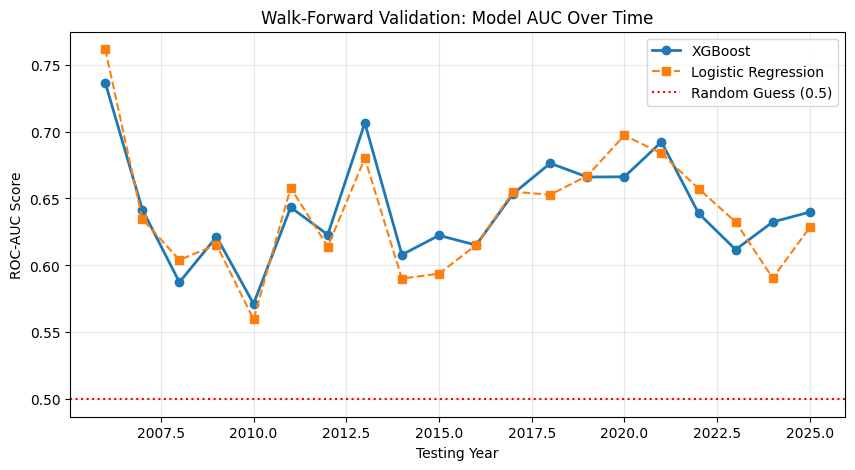

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(test_years, xgb_auc_scores, marker='o', label='XGBoost', linewidth=2)
plt.plot(test_years, lr_auc_scores, marker='s', label='Logistic Regression', linestyle='--')
plt.axhline(0.5, color='red', linestyle=':', label='Random Guess (0.5)')
plt.title('Walk-Forward Validation: Model AUC Over Time')
plt.xlabel('Testing Year')
plt.ylabel('ROC-AUC Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()